# Section A: K-Means Clustering & Elbow Method

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

## 1.Load the Iris dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2.Using Elbow Method to determine the optimal number of clusters

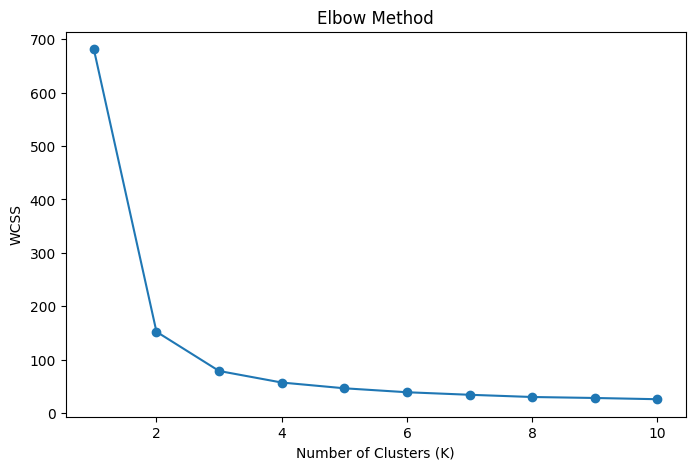

In [3]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 3.Apply K-Means clustering

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


## 4.Plot clusters in 2D (first two features)

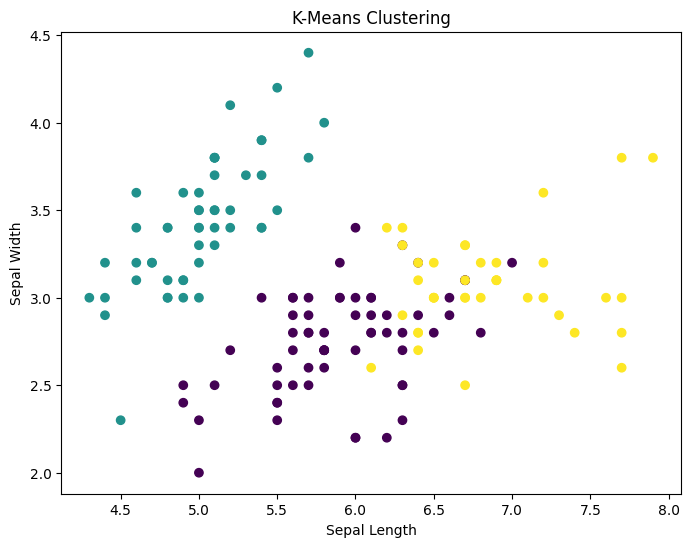

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(X[:,0],X[:,1],c=clusters,cmap='viridis')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering")
plt.show()

# Section B: Principal Component Analysis

## 1.Apply PCA on the Iris dataset to reduce it to 2 dimensions

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

## 2.Plot PCA

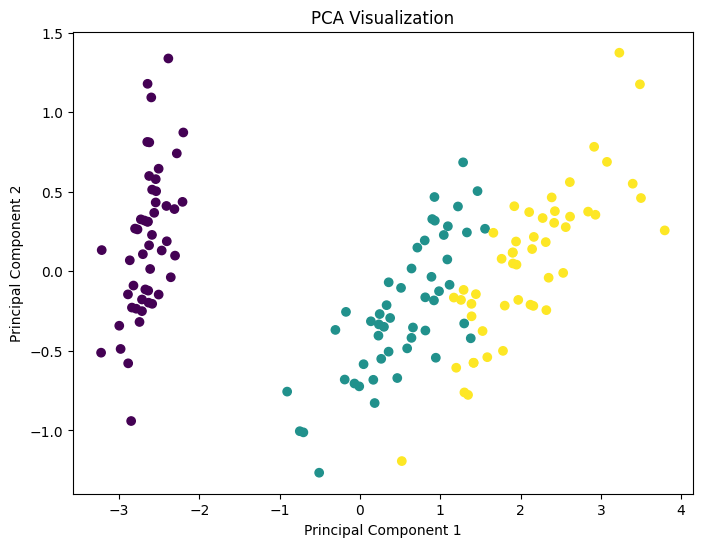

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.show()

## 3.Explained variance ratio

In [8]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(explained_variance)
print(cumulative_variance)

[0.92461872 0.05306648]
[0.92461872 0.97768521]


## 4.Compare clustering results on PCA-reduced data vs original data

In [9]:
# K-Means on PCA Data
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

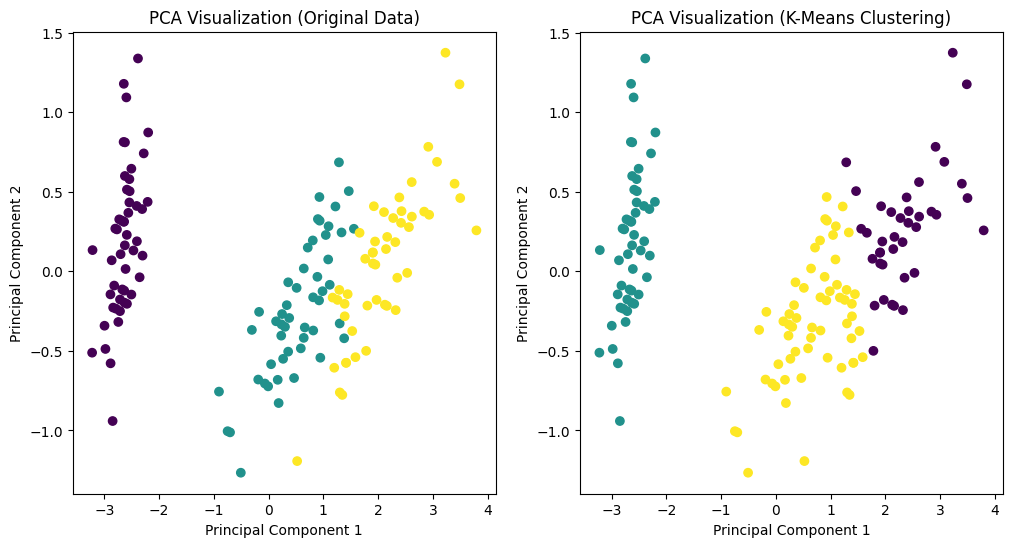

In [10]:
# Compare clustering results on PCA-reduced data vs original data
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization (Original Data)")

plt.subplot(1,2,2)
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters_pca,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization (K-Means Clustering)")

plt.show()

# Section C: Hierarchical Clustering

## 1.Draw a dendrogram

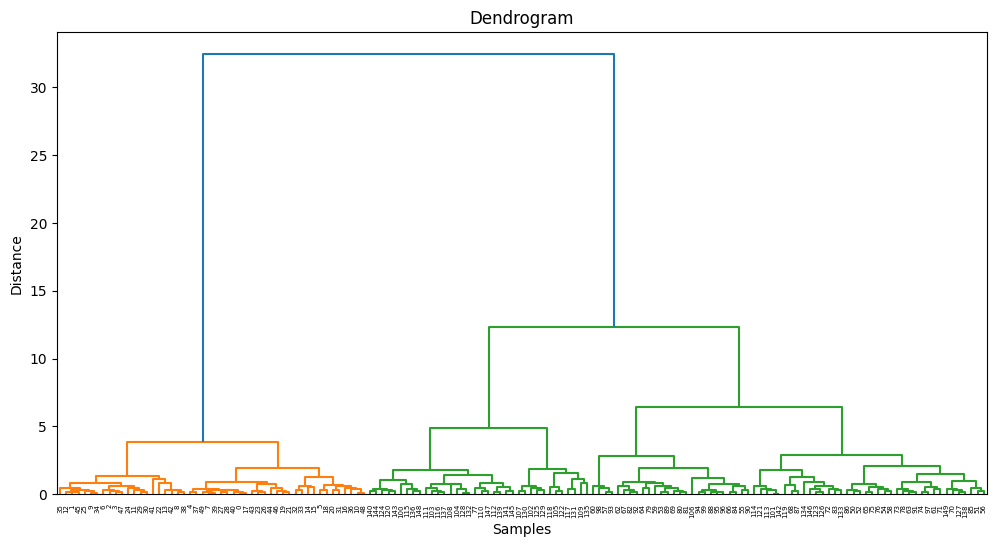

In [11]:
linked = linkage(
    X,
    method='ward'
)
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

## 2.Apply Hierarchical Clustering on the Iris dataset

In [12]:
hc = AgglomerativeClustering(
    n_clusters=3
)

hc_labels = hc.fit_predict(X)

## 3.Compare clusters with K-Means results

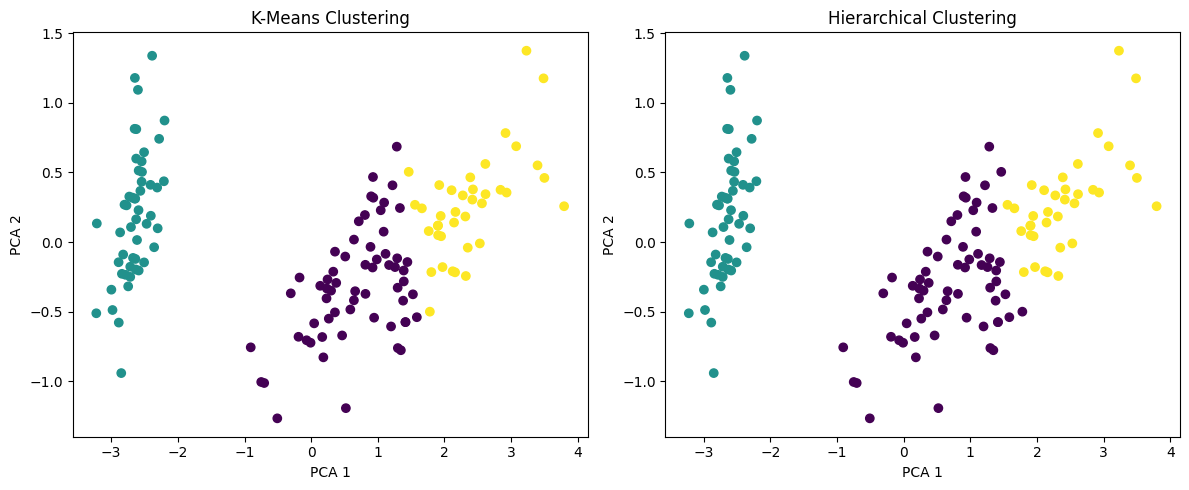

In [13]:
plt.figure(figsize=(12, 5))

# K-Means Plot
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Hierarchical Clustering Plot
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

**Comparison between K-Means and Hierarchical Clustering**:
Both K-Means and Agglomerative Hierarchical Clustering successfully grouped the Iris dataset into three distinct clusters. Visually, the cluster assignments for both algorithms are almost identical. The Setosa class is perfectly isolated in both models. However, there is a slight overlap between the Versicolor and Virginica classes. Because K-Means assumes spherical clusters and Hierarchical Clustering (using Ward's linkage) minimizes variance, their decision boundaries in that overlapping region might differ by just one or two data points. Overall, both algorithms perform excellently and yield highly comparable results for this dataset.

# Section D: DBSCAN

## 1.Apply DBSCAN

In [14]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X)

## 2.Experiment with different values and Plot clusters with noise

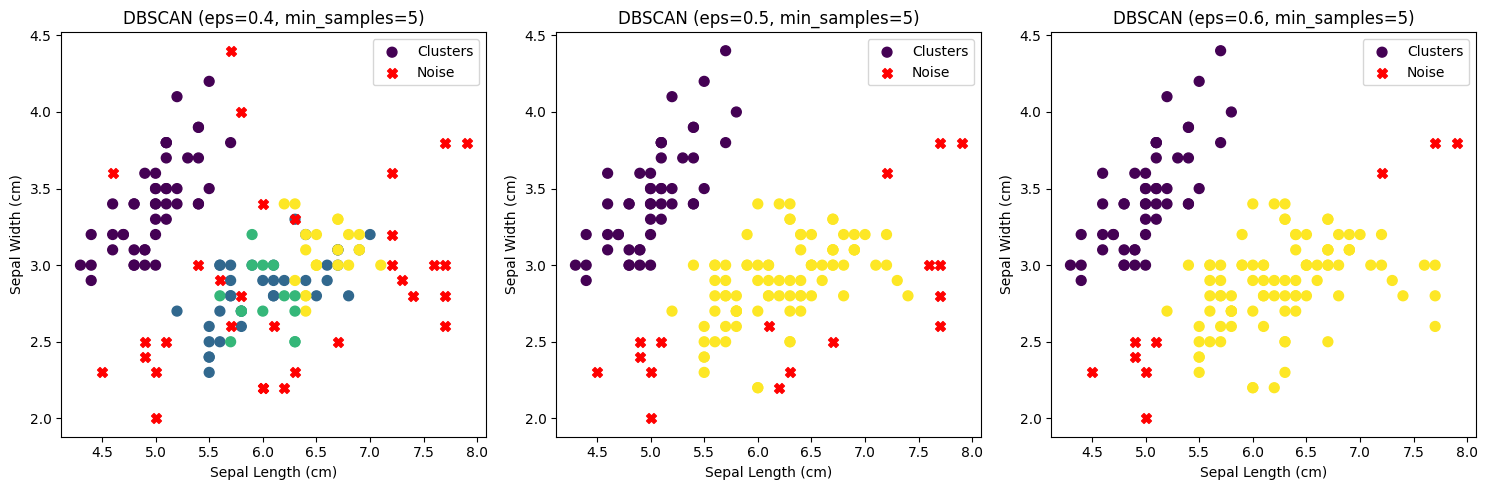

In [15]:
# Testing 3 different combinations of eps and min_samples
param_combinations = [(0.4, 5), (0.5, 5), (0.6, 5)]

plt.figure(figsize=(15, 5))

for i, (epsilon, min_s) in enumerate(param_combinations):
    # Apply DBSCAN on original data X
    db = DBSCAN(eps=epsilon, min_samples=min_s)
    labels = db.fit_predict(X)

    # Create masks for core points and noise points
    core_mask = labels != -1  # Normal cluster points
    noise_mask = labels == -1 # Noise points get the label -1

    # Plotting using the first two features of original data X (Sepal Length vs Sepal Width)
    plt.subplot(1, 3, i+1)

    # Plot core points
    plt.scatter(X[core_mask, 0], X[core_mask, 1], c=labels[core_mask], cmap='viridis', label='Clusters', s=50)

    # Highlight noise points with red 'X'
    plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='red', marker='X', label='Noise', s=50)

    plt.title(f'DBSCAN (eps={epsilon}, min_samples={min_s})')
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.legend()

plt.tight_layout()
plt.show()

## 3.Compare DBSCAN clusters with K-Means clusters

**Comparison between DBSCAN and K-Means:**

**Cluster Assignment**: K-Means forces every single data point into one of the clusters, even if the point is an outlier. DBSCAN isolates outliers and labels them as "Noise" (shown as red crosses in the plots) rather than forcing them into a cluster.

**Number of Clusters**: For K-Means, we had to pre-define the number of clusters as k=3. DBSCAN automatically infers the number of clusters based on the dataset's density and the provided eps and min_samples parameters.

**Performance on Iris Dataset**: The Iris dataset has a clear separation for the Setosa class but heavily overlapping regions for Versicolor and Virginica. Because of this density overlap, DBSCAN struggles to cleanly separate Versicolor and Virginica into two distinct clusters using the original features, often merging them into a single dense cluster or classifying the overlapping boundary points as noise. K-Means handles this specific dataset's spherical separation slightly better than DBSCAN.